# Probability calibration

### Getting a predicted 0.8 to mean eight times out of ten

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | Why ranking cases correctly and predicting honest probabilities are two separate skills, how to read a reliability diagram, how to write expected calibration error yourself in a few lines of NumPy, the shape of miscalibration each model family produces, and when Platt scaling beats isotonic regression |
| **You should already know** | [Logistic regression](../01-logistic-regression/), [naive Bayes](../03-naive-bayes/), [support vector machines](../05-support-vector-machines/), [classification metrics](../../01-foundations/05-classification-metrics/), [cross-validation](../../01-foundations/04-cross-validation/) |
| **Datasets** | UCI Breast Cancer Wisconsin, UCI Dry Bean |
| **Runtime** | Under two minutes on a laptop CPU |
| **Next** | [04-01 Bagging](../../04-ensembles/01-bagging/) |

---

## 1. Ranking is not the same as probability

Every classifier in this chapter has a `predict_proba` method, and it is tempting
to read what comes out of it as a probability. Most of the time it is not one. It
is a score that happens to live between 0 and 1.

Two separate questions hide behind that number.

**Discrimination** asks whether the model puts the positive cases above the
negative ones. That is what [ROC AUC](../../01-foundations/05-classification-metrics/)
measures, and it depends only on the *order* of the scores.

**Calibration** asks whether the number is true. Of all the cases the model
scored 0.80, do about 80% turn out positive? That depends on the *values*.

AUC cannot see calibration at all. Squeeze every score into a narrow band around
0.9, or cube them, or run them through any other increasing function, and the
order does not move, so the AUC does not move either. The probabilities become
nonsense and the metric stays silent. If you ever act on the number rather than
on the ranking (a threshold set by a cost, an expected value, a probability
passed to a downstream model), that silence is expensive.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style, evaluate

style.use()
FIG = pathlib.Path("figures")
SEED = 0

The cleanest way to see that the two are independent is to build the two extreme
cases by hand. First a model that ranks perfectly and lies about every
probability, then a model that ranks at chance and tells the truth about every
probability.

In [2]:
from sklearn.metrics import roc_auc_score, accuracy_score, brier_score_loss

rng = np.random.default_rng(SEED)
hidden = rng.normal(0, 1, 4000)
label = (hidden > np.quantile(hidden, 0.70)).astype(int)  # 30% positive by construction

# A perfect ranker: strictly increasing in `hidden`, so the order is exactly right.
# It is also squashed into a narrow band near 0.9, so every value is a lie.
rank = (hidden - hidden.min()) / (hidden.max() - hidden.min())
perfect_ranker = 0.90 + 0.02 * rank

# A perfectly calibrated model with no ability to tell anything apart.
base_rate_only = np.full_like(hidden, label.mean())

print("perfect ranker, useless probabilities")
print(f"  AUC       {roc_auc_score(label, perfect_ranker):.4f}")
print(f"  ECE       {evaluate.expected_calibration_error(label, perfect_ranker, n_bins=15):.4f}")
print(f"  accuracy at threshold 0.5   {accuracy_score(label, perfect_ranker > 0.5):.4f}")
print(f"  positives in the data       {label.mean():.4f}")

print("\nperfectly calibrated, no discrimination")
print(f"  AUC       {roc_auc_score(label, base_rate_only):.4f}")
print(f"  ECE       {evaluate.expected_calibration_error(label, base_rate_only, n_bins=15):.4f}")

perfect ranker, useless probabilities
  AUC       1.0000
  ECE       0.6109
  accuracy at threshold 0.5   0.3000
  positives in the data       0.3000

perfectly calibrated, no discrimination
  AUC       0.5000
  ECE       0.0000


The first model orders every case correctly and still claims about a 91% chance
for cases that are mostly negative, and at the default threshold it labels
everything positive. The second model has nothing to say about any individual
case and its probabilities are exactly right on average.

Neither is useful, and no single number catches both failures. You need one
metric for each question.

The same thing happens on real data. I take a logistic regression on the breast
cancer data, then distort its probabilities in logit space, dividing the logit
by a temperature $T$. With $T < 1$ the model becomes more confident, with
$T > 1$ less confident. Both are increasing functions of the original score, so
the ranking, and therefore the AUC, is identical to the last decimal.

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X_bc, y_bc = datasets.breast_cancer()
X_bc, y_bc = X_bc.values, y_bc.values
folds = StratifiedKFold(5, shuffle=True, random_state=SEED)


def logit(p, eps=1e-9):
    """Inverse of the sigmoid, with clipping so 0 and 1 do not become infinite."""
    p = np.clip(p, eps, 1 - eps)
    return np.log(p / (1 - p))


def temper(p, T):
    """Divide the logit by T. T < 1 sharpens, T > 1 flattens. Order is preserved."""
    return 1 / (1 + np.exp(-logit(p) / T))


# Out-of-fold predictions, because a model's probabilities on its own training
# rows are optimistic and calibration measured there is meaningless.
honest = cross_val_predict(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
                           X_bc, y_bc, cv=folds, method="predict_proba")[:, 1]

variants = {"as fitted": honest,
            "over-confident (T=0.3)": temper(honest, 0.3),
            "under-confident (T=3.0)": temper(honest, 3.0)}

variant_ece = {name: evaluate.expected_calibration_error(y_bc, p, n_bins=15)
               for name, p in variants.items()}
variant_brier = {name: brier_score_loss(y_bc, p) for name, p in variants.items()}

for name, p in variants.items():
    print(f"{name:26s} AUC {roc_auc_score(y_bc, p):.6f}   "
          f"ECE {variant_ece[name]:.4f}   Brier {variant_brier[name]:.4f}")

# "As fitted" is a description of what I did, not a verdict. Check it.
print(f"\nover-confident minus as fitted: "
      f"ECE {variant_ece['over-confident (T=0.3)'] - variant_ece['as fitted']:+.4f}, "
      f"Brier {variant_brier['over-confident (T=0.3)'] - variant_brier['as fitted']:+.4f}")

as fitted                  AUC 0.995283   ECE 0.0197   Brier 0.0195
over-confident (T=0.3)     AUC 0.995283   ECE 0.0184   Brier 0.0186
under-confident (T=3.0)    AUC 0.995283   ECE 0.1063   Brier 0.0381

over-confident minus as fitted: ECE -0.0013, Brier -0.0009


AUC spread across the three variants: 0.0000000000
ECE spread across the three variants: 0.0878


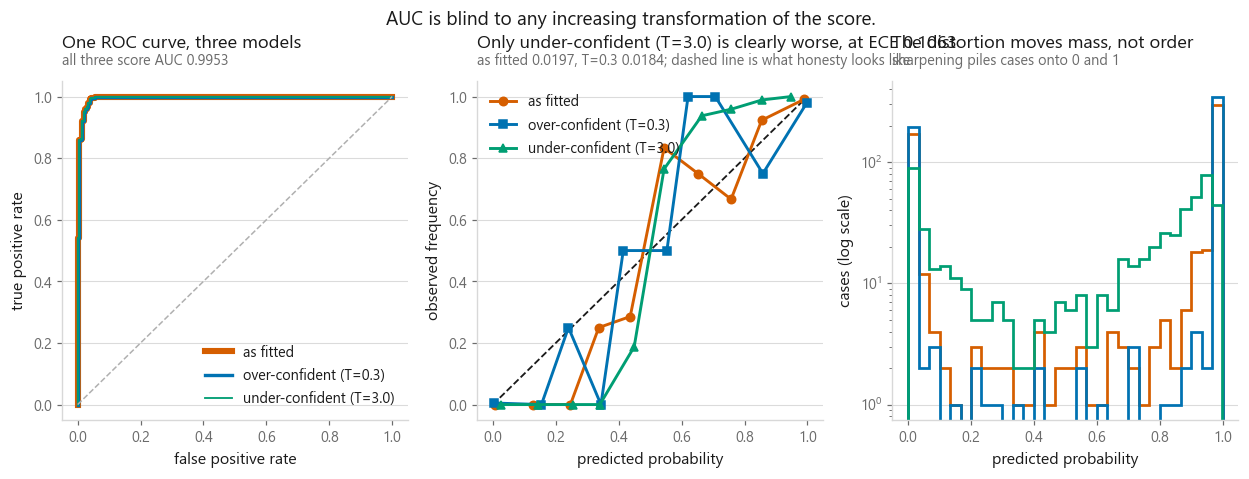

In [4]:
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(13.8, 4.0))
colours = [style.HIGHLIGHT, style.PALETTE[0], style.PALETTE[2]]
widths = [4.0, 2.2, 1.2]

# Panel 1: three ROC curves drawn on top of one another, thickest first so the
# thinner ones stay visible where they overlap, which is everywhere.
for (name, p), c, w in zip(variants.items(), colours, widths):
    fpr, tpr, _ = roc_curve(y_bc, p)
    axes[0].plot(fpr, tpr, color=c, lw=w, label=name)
axes[0].plot([0, 1], [0, 1], color=style.NEUTRAL, ls="--", lw=1)
axes[0].set_xlabel("false positive rate")
axes[0].set_ylabel("true positive rate")
axes[0].legend(loc="lower right")
style.title(axes[0], "One ROC curve, three models",
            f"all three score AUC {roc_auc_score(y_bc, honest):.4f}")

# Panel 2: the same three, judged on the value of the number instead of its rank
axes[1].plot([0, 1], [0, 1], color=style.INK, ls="--", lw=1.2)
for (name, p), c, m in zip(variants.items(), colours, style.MARKERS):
    pred, obs, _ = evaluate.reliability_curve(y_bc, p, n_bins=10)
    axes[1].plot(pred, obs, marker=m, color=c, label=name)
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("observed frequency")
axes[1].legend(loc="upper left")
worst_variant = max(variant_ece, key=variant_ece.get)
style.title(axes[1],
            f"Only {worst_variant} is clearly worse, at ECE {variant_ece[worst_variant]:.4f}",
            f"as fitted {variant_ece['as fitted']:.4f}, T=0.3 "
            f"{variant_ece['over-confident (T=0.3)']:.4f}; "
            "dashed line is what honesty looks like")

# Panel 3: where the distortion actually went
for (name, p), c in zip(variants.items(), colours):
    axes[2].hist(p, bins=30, histtype="step", lw=1.8, color=c, label=name)
axes[2].set_yscale("log")
axes[2].set_xlabel("predicted probability")
axes[2].set_ylabel("cases (log scale)")
style.title(axes[2], "The distortion moves mass, not order",
            "sharpening piles cases onto 0 and 1")

fig.suptitle("AUC is blind to any increasing transformation of the score.",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-01-ranking-is-not-probability.png")

print("AUC spread across the three variants: "
      f"{max(roc_auc_score(y_bc, p) for p in variants.values()) - min(roc_auc_score(y_bc, p) for p in variants.values()):.10f}")
print("ECE spread across the three variants: "
      f"{max(evaluate.expected_calibration_error(y_bc, p, n_bins=15) for p in variants.values()) - min(evaluate.expected_calibration_error(y_bc, p, n_bins=15) for p in variants.values()):.4f}")

The left panel is the whole argument in one picture. Three models, one curve,
because AUC only ever sees the order.

The middle panel is meant to separate all three, and it separates one. The
under-confident variant is plainly worse, ECE 0.1063 against 0.0197 and Brier
0.0381 against 0.0195. **The over-confident variant is not worse. It is
marginally better**, ECE 0.0184 and Brier 0.0186, beating the baseline on both.

I had labelled that baseline "as fitted" as though the phrase were a verdict.
It is a description of what I did to the model, nothing more. An out-of-fold
logistic regression on this data is already close to calibrated, and dividing
its logits by 0.3 nudges it a hair *toward* the diagonal rather than away from
it. Two of these three curves are calibration-equivalent, and eyeballing the
diagram would not tell you which two.

The lesson survives and sharpens. A reliability diagram shows you the shape of
the error. It does not rank models, because curves that look different can
score the same. Put a number underneath it.

## 2. Reliability diagrams and expected calibration error

A reliability diagram is the honest picture. Sort the predictions into bins,
and for each bin plot the mean predicted probability against the fraction of
cases in that bin that were actually positive. A calibrated model lands on the
diagonal. Above the diagonal means the model is under-confident: reality
happened more often than it said. Below means over-confident.

**Expected calibration error** turns that picture into one number. Split the
predictions into $B$ bins, take the gap between prediction and reality inside
each bin, and average the gaps weighted by how many cases fell in each:

$$\mathrm{ECE} = \sum_{b=1}^{B} \frac{n_b}{n} \left| \; \bar{y}_b - \bar{p}_b \; \right|$$

where $n_b$ is the number of cases in bin $b$, $\bar{p}_b$ their mean predicted
probability, and $\bar{y}_b$ the fraction of them that were positive. Nothing
else is going on. Here it is twice, once as a loop that reads like the formula
and once vectorised, checked against the version in `toolkit.evaluate`.

In [5]:
def ece_loop(y_true, y_prob, n_bins=15):
    """ECE written the way the formula reads, one bin at a time."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    # digitize against the interior edges so 0.0 falls in the first bin and 1.0
    # in the last, instead of spilling into bins that do not exist
    which = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)

    total = 0.0
    for b in range(n_bins):
        in_bin = which == b
        if not in_bin.any():
            continue
        weight = in_bin.mean()                 # n_b / n
        confidence = y_prob[in_bin].mean()     # mean predicted
        observed = y_true[in_bin].mean()       # fraction actually positive
        total += weight * abs(observed - confidence)
    return float(total)


def ece_vectorised(y_true, y_prob, n_bins=15):
    """The same sum with bincount, which is what you want inside a loop."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    edges = np.linspace(0.0, 1.0, n_bins + 1)
    which = np.clip(np.digitize(y_prob, edges[1:-1]), 0, n_bins - 1)

    counts = np.bincount(which, minlength=n_bins).astype(float)
    sum_prob = np.bincount(which, weights=y_prob, minlength=n_bins)
    sum_true = np.bincount(which, weights=y_true, minlength=n_bins)
    filled = counts > 0
    gaps = np.abs(sum_true[filled] / counts[filled] - sum_prob[filled] / counts[filled])
    return float(np.sum(counts[filled] / counts.sum() * gaps))


check = temper(honest, 0.3)
print(f"loop        {ece_loop(y_bc, check):.10f}")
print(f"vectorised  {ece_vectorised(y_bc, check):.10f}")
print(f"toolkit     {evaluate.expected_calibration_error(y_bc, check, n_bins=15):.10f}")
assert np.isclose(ece_loop(y_bc, check), evaluate.expected_calibration_error(y_bc, check, n_bins=15))

loop        0.0184214056
vectorised  0.0184214056
toolkit     0.0184214056


Two things about ECE that the single number hides.

It depends on the binning. Equal-width bins, which is what I use, leave the
high-confidence bins holding most of the data, so most of the weight comes from
a couple of bins near 0 and 1. Equal-count bins spread the weight evenly and
usually report a smaller number for the same model. Neither is wrong, but ECE
from two papers is only comparable if the binning matches.

It is also not a proper scoring rule. Predicting the base rate for every case
gives ECE near zero, as section 1 showed. **Report ECE next to the Brier score
or the log loss**, which do punish a model for refusing to discriminate. The
Brier score is the mean squared error of the probabilities, and it decomposes
into a calibration part and a resolution part, so it moves for either failure.

Below is one model's reliability diagram with the bin populations drawn
underneath, because a bin holding four cases and a bin holding three hundred
look identical on the top panel and should not.

 mean predicted  observed    gap  cases
          0.014     0.000 -0.014    155
          0.150     0.000 -0.150     22
          0.245     0.182 -0.063     11
          0.341     0.250 -0.091      8
          0.458     0.444 -0.013      9
          0.549     0.417 -0.132     12
          0.664     0.818  0.154     11
          0.736     0.800  0.064     15
          0.854     1.000  0.146     30
          0.985     0.990  0.005    296

share of cases in the two end bins: 0.793


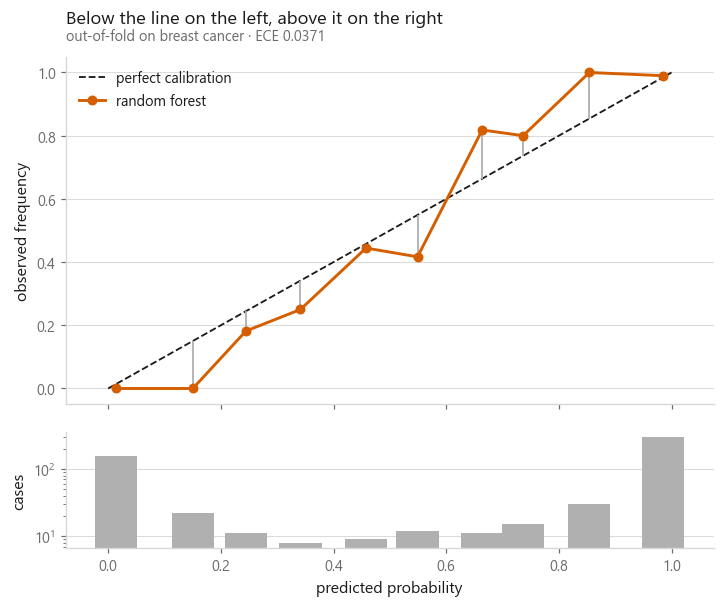

In [6]:
from sklearn.ensemble import RandomForestClassifier

forest_probs = cross_val_predict(RandomForestClassifier(n_estimators=300, random_state=SEED),
                                 X_bc, y_bc, cv=folds, method="predict_proba", n_jobs=5)[:, 1]

pred, obs, counts = evaluate.reliability_curve(y_bc, forest_probs, n_bins=10)

fig, axes = plt.subplots(2, 1, figsize=(7.6, 5.8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1], "hspace": 0.12})

axes[0].plot([0, 1], [0, 1], color=style.INK, ls="--", lw=1.2, label="perfect calibration")
axes[0].vlines(pred, np.minimum(pred, obs), np.maximum(pred, obs),
               color=style.NEUTRAL, lw=1.2)
axes[0].plot(pred, obs, marker=style.MARKERS[0], color=style.HIGHLIGHT, label="random forest")
axes[0].set_ylabel("observed frequency")
axes[0].legend(loc="upper left")
style.title(axes[0], "Below the line on the left, above it on the right",
            f"out-of-fold on breast cancer · ECE {evaluate.expected_calibration_error(y_bc, forest_probs, n_bins=15):.4f}")

axes[1].bar(pred, counts, width=0.075, color=style.NEUTRAL)
axes[1].set_yscale("log")
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("cases")
axes[1].grid(axis="y", visible=True)

style.save(fig, FIG / "fig-02-reliability-and-bins.png")

table = pd.DataFrame({"mean predicted": pred.round(3),
                      "observed": obs.round(3),
                      "gap": (obs - pred).round(3),
                      "cases": counts})
print(table.to_string(index=False))
print(f"\nshare of cases in the two end bins: {(counts[0] + counts[-1]) / counts.sum():.3f}")

The gap column changes sign as you move left to right, and the case counts show
that almost all the data sits in the two extreme bins. That combination of
facts is the signature of the next section.

## 3. How common models are miscalibrated

Model families are wrong in characteristic ways, and once you know the shape you
can guess the fix before measuring it. I fit four of them on breast cancer with
out-of-fold predictions, so nothing is scored on rows it trained on.

In [7]:
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

models = {
    "logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)),
    "random forest": RandomForestClassifier(n_estimators=300, random_state=SEED),
    "naive Bayes": GaussianNB(),
}

scores = {name: cross_val_predict(model, X_bc, y_bc, cv=folds,
                                  method="predict_proba", n_jobs=5)[:, 1]
          for name, model in models.items()}

# The SVM has no predict_proba by default. What it has is a signed distance from
# the boundary, on a scale set by the data, not by probability.
svm = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
margin = cross_val_predict(svm, X_bc, y_bc, cv=folds, method="decision_function", n_jobs=5)
scores["SVM margin, min-max squashed"] = (margin - margin.min()) / (margin.max() - margin.min())

summary = pd.DataFrame([{
    "model": name,
    "AUC": round(roc_auc_score(y_bc, p), 4),
    "accuracy": round(accuracy_score(y_bc, p > 0.5), 4),
    "Brier": round(brier_score_loss(y_bc, p), 4),
    "ECE": round(evaluate.expected_calibration_error(y_bc, p, n_bins=15), 4),
} for name, p in scores.items()])
print(summary.to_string(index=False))

                       model    AUC  accuracy  Brier    ECE
         logistic regression 0.9953    0.9789 0.0195 0.0197
               random forest 0.9907    0.9578 0.0301 0.0371
                 naive Bayes 0.9877    0.9385 0.0568 0.0603
SVM margin, min-max squashed 0.9953    0.9754 0.0654 0.1927


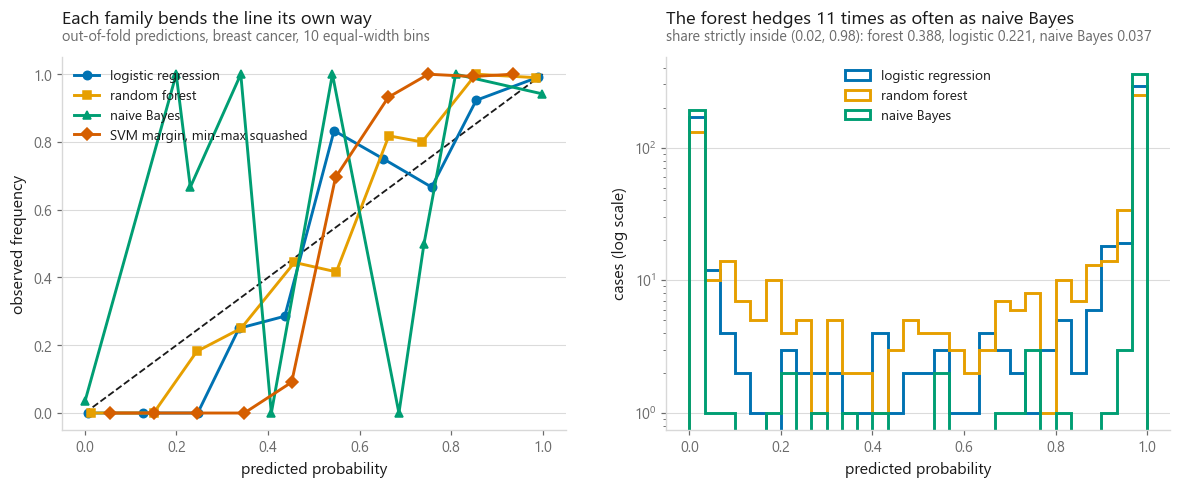

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

axes[0].plot([0, 1], [0, 1], color=style.INK, ls="--", lw=1.2)
for i, (name, p) in enumerate(scores.items()):
    pred_i, obs_i, _ = evaluate.reliability_curve(y_bc, p, n_bins=10)
    axes[0].plot(pred_i, obs_i, marker=style.MARKERS[i], color=style.PALETTE[i], label=name)
axes[0].set_xlabel("predicted probability")
axes[0].set_ylabel("observed frequency")
axes[0].legend(loc="upper left", fontsize=9)
style.title(axes[0], "Each family bends the line its own way",
            "out-of-fold predictions, breast cancer, 10 equal-width bins")

for i, name in enumerate(models):
    axes[1].hist(scores[name], bins=30, histtype="step", lw=1.9,
                 color=style.PALETTE[i], label=name)
axes[1].set_yscale("log")
axes[1].set_xlabel("predicted probability")
axes[1].set_ylabel("cases (log scale)")
axes[1].legend(loc="upper center", fontsize=9)
middle = {name: float(((scores[name] > 0.02) & (scores[name] < 0.98)).mean())
          for name in models}
style.title(axes[1],
            f"The forest hedges {middle['random forest'] / middle['naive Bayes']:.0f} times "
            f"as often as naive Bayes",
            f"share strictly inside (0.02, 0.98): forest {middle['random forest']:.3f}, "
            f"logistic {middle['logistic regression']:.3f}, "
            f"naive Bayes {middle['naive Bayes']:.3f}")

style.save(fig, FIG / "fig-03-shapes-of-miscalibration.png")

### The random forest averages votes, so it hedges more often

A forest prediction is the share of trees voting positive. For that share to
reach 1.0 every tree has to agree, and on a case near a boundary a few trees
dissent, so the prediction lands somewhere in between. That is the mechanism,
and it draws the S-curve in the figure above: below the diagonal on the left,
above it on the right, which is under-confidence.

**The tempting next sentence is that the floor and ceiling become unreachable,
and that sentence is false.** The print below reports min 0.0000 and max 1.0000
for the forest, and the bin table in section 2 put 0.793 of its cases in the two
end bins. Most breast cancer cases are nowhere near a boundary, and on those
every one of the 300 trees agrees and the vote is unanimous.

What the forest actually does is hedge *more often than the others*, and the
print below is the way to see it: 0.388 of its predictions fall strictly inside
(0.02, 0.98), against 0.221 for logistic regression and 0.037 for naive Bayes.
The middle is fuller, not full. That difference is enough to bend the
reliability curve, and it is a smaller claim than "never commits".

The same averaging is what makes forests accurate. The cost is on the
probability scale.

In [9]:
for name in ["logistic regression", "random forest", "naive Bayes"]:
    p = scores[name]
    print(f"{name:22s} min {p.min():.4f}  max {p.max():.4f}  "
          f"share strictly inside (0.02, 0.98): {((p > 0.02) & (p < 0.98)).mean():.3f}")

logistic regression    min 0.0000  max 1.0000  share strictly inside (0.02, 0.98): 0.221
random forest          min 0.0000  max 1.0000  share strictly inside (0.02, 0.98): 0.388
naive Bayes            min 0.0000  max 1.0000  share strictly inside (0.02, 0.98): 0.037


### The SVM margin is not a probability and never was

`decision_function` returns a signed distance from the separating hyperplane in
the kernel's feature space. Its units are whatever the data made them. It is not
bounded, it has no probabilistic meaning, and the only reason the squashed
version plots at all above is that I rescaled it by hand.

In [10]:
print(f"margin range: [{margin.min():.3f}, {margin.max():.3f}]")
print(f"AUC from the raw margin        {roc_auc_score(y_bc, margin):.4f}")
print(f"AUC after min-max squashing    {roc_auc_score(y_bc, scores['SVM margin, min-max squashed']):.4f}")
print(f"ECE after min-max squashing    {evaluate.expected_calibration_error(y_bc, scores['SVM margin, min-max squashed'], n_bins=15):.4f}")
print(f"ECE if I pass it through a plain sigmoid instead  "
      f"{evaluate.expected_calibration_error(y_bc, 1 / (1 + np.exp(-margin)), n_bins=15):.4f}")

margin range: [-2.765, 2.592]
AUC from the raw margin        0.9953
AUC after min-max squashing    0.9953
ECE after min-max squashing    0.1927
ECE if I pass it through a plain sigmoid instead  0.1753


Both squashes rank identically and both are badly calibrated, because neither
looked at the labels. Turning a margin into a probability needs a fitted map,
which is exactly what section 4 does. `SVC(probability=True)` already does this
internally, and the fact that it can disagree with `predict` is a consequence:
the probability comes from a separate fit, not from the margin sign.

### Naive Bayes multiplies away its own doubt

Naive Bayes multiplies per-feature likelihoods as if the features were
independent. On the breast cancer data they are heavily correlated (several
columns are near-copies of each other), so the same evidence gets counted many
times over and the posterior is driven to the extremes. The
[naive Bayes notebook](../03-naive-bayes/) ran into this directly: nearly all of
its predictions came out at the very top of the confidence range while its
accuracy sat far below that. The measurement repeats here.

In [11]:
nb_probs = scores["naive Bayes"]
confidence = np.maximum(nb_probs, 1 - nb_probs)
very_sure = confidence > 0.99

print(f"share of predictions above 0.99 confidence : {very_sure.mean():.4f}")
print(f"accuracy on those predictions              : {accuracy_score(y_bc[very_sure], nb_probs[very_sure] > 0.5):.4f}")
print(f"overall accuracy                           : {accuracy_score(y_bc, nb_probs > 0.5):.4f}")
print(f"mean confidence                            : {confidence.mean():.4f}")

share of predictions above 0.99 confidence : 0.9561
accuracy on those predictions              : 0.9577
overall accuracy                           : 0.9385
mean confidence                            : 0.9919


Confidence far above accuracy is the definition of over-confidence: mean
confidence 0.9919 against 0.9385 accuracy. Of the models here that are actually
trying to emit probabilities, naive Bayes has the widest such gap.

It is not the worst calibration in the chapter, and the four-model table above
says so: naive Bayes scores ECE 0.0603, while the min-max squashed SVM margin
scores 0.1927, three times worse. The two failures are different in kind. Naive
Bayes is badly wrong about a quantity it set out to estimate. The SVM margin was
never estimating a probability at all, and I only got a number between 0 and 1
out of it by rescaling it by hand.

Naive Bayes' ranking is still fine, which is why it survives as a baseline.

## 4. Platt scaling against isotonic regression

Both methods fit a function from the model's raw score to a probability, using
labelled data the model did not train on. They differ in what they are allowed
to fit.

**Platt scaling** fits a sigmoid, so it learns two numbers: a slope and an
offset. It can sharpen, flatten, or shift a curve, and nothing else. If the
miscalibration is a smooth S it fixes it exactly. If it has a different shape,
a sigmoid cannot get there.

**Isotonic regression** fits any non-decreasing step function that minimises
squared error. It can bend into any monotone shape, which also means it can bend
into the noise of the calibration set.

`CalibratedClassifierCV` wraps either one. In scikit-learn 1.8 the model goes in
as `estimator`, and `cv` controls how the held-out predictions are produced. I
nest the whole wrapper inside an outer cross-validation loop below so that the
calibrated and uncalibrated numbers are measured on the same footing.

In [12]:
from sklearn.calibration import CalibratedClassifierCV

candidates = dict(models)
candidates["SVM (rbf)"] = svm

rows = []
calibrated = {}
for name, model in candidates.items():
    raw = scores[name] if name in scores else scores["SVM margin, min-max squashed"]
    rows.append({"model": name, "calibration": "none",
                 "AUC": round(roc_auc_score(y_bc, raw), 4),
                 "Brier": round(brier_score_loss(y_bc, raw), 4),
                 "ECE": round(evaluate.expected_calibration_error(y_bc, raw, n_bins=15), 4)})
    for method in ["sigmoid", "isotonic"]:
        wrapped = CalibratedClassifierCV(estimator=model, method=method, cv=5)
        p = cross_val_predict(wrapped, X_bc, y_bc, cv=folds,
                              method="predict_proba", n_jobs=5)[:, 1]
        calibrated[(name, method)] = p
        rows.append({"model": name, "calibration": method,
                     "AUC": round(roc_auc_score(y_bc, p), 4),
                     "Brier": round(brier_score_loss(y_bc, p), 4),
                     "ECE": round(evaluate.expected_calibration_error(y_bc, p, n_bins=15), 4)})

calibration_table = pd.DataFrame(rows)
print(calibration_table.to_string(index=False))

# Calibration is supposed to leave the order alone. Check whether it did.
auc_shift = (calibration_table.pivot(index="model", columns="calibration", values="AUC")
             .pipe(lambda t: t[["sigmoid", "isotonic"]].sub(t["none"], axis=0)))
print("\nAUC change against the uncalibrated model:")
print(auc_shift.round(4).to_string())
print(f"largest move: {auc_shift.abs().max().max():.4f}")

              model calibration    AUC  Brier    ECE
logistic regression        none 0.9953 0.0195 0.0197
logistic regression     sigmoid 0.9957 0.0269 0.0571
logistic regression    isotonic 0.9938 0.0178 0.0119
      random forest        none 0.9907 0.0301 0.0371
      random forest     sigmoid 0.9913 0.0281 0.0358
      random forest    isotonic 0.9886 0.0300 0.0191
        naive Bayes        none 0.9877 0.0568 0.0603
        naive Bayes     sigmoid 0.9454 0.0551 0.0418
        naive Bayes    isotonic 0.9854 0.0444 0.0332
          SVM (rbf)        none 0.9953 0.0654 0.1927
          SVM (rbf)     sigmoid 0.9945 0.0240 0.0433
          SVM (rbf)    isotonic 0.9931 0.0206 0.0159

AUC change against the uncalibrated model:
calibration          sigmoid  isotonic
model                                 
SVM (rbf)            -0.0008   -0.0022
logistic regression   0.0004   -0.0015
naive Bayes          -0.0423   -0.0023
random forest         0.0006   -0.0021
largest move: 0.0423


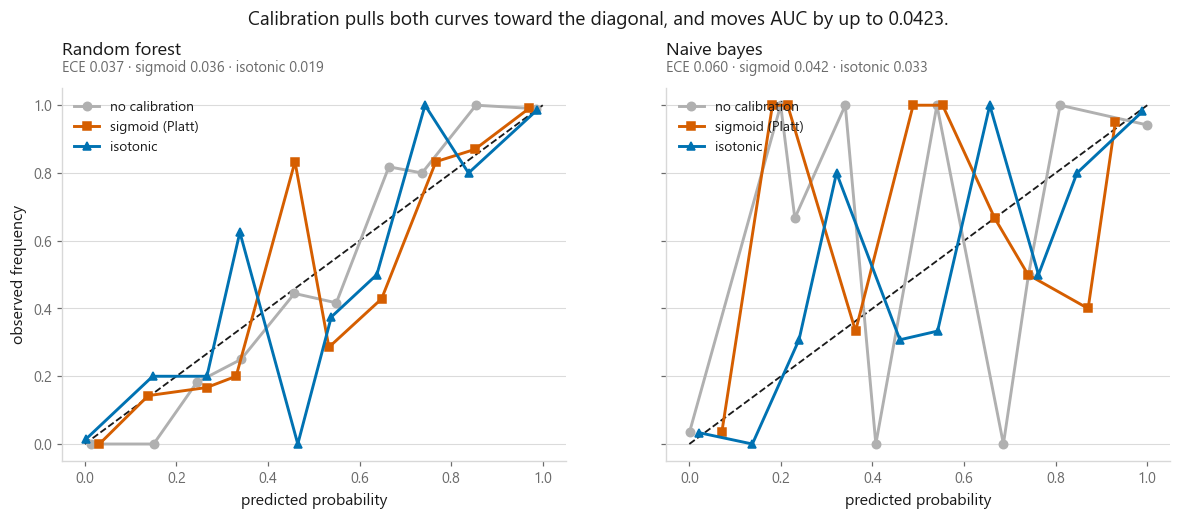

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4), sharey=True)

for ax, name in zip(axes, ["random forest", "naive Bayes"]):
    ax.plot([0, 1], [0, 1], color=style.INK, ls="--", lw=1.2)
    series = [("no calibration", scores[name], style.NEUTRAL),
              ("sigmoid (Platt)", calibrated[(name, "sigmoid")], style.HIGHLIGHT),
              ("isotonic", calibrated[(name, "isotonic")], style.PALETTE[0])]
    for i, (label_i, p, colour) in enumerate(series):
        pred_i, obs_i, _ = evaluate.reliability_curve(y_bc, p, n_bins=10)
        ax.plot(pred_i, obs_i, marker=style.MARKERS[i], color=colour, label=label_i)
    ax.set_xlabel("predicted probability")
    ax.legend(loc="upper left", fontsize=9)
    style.title(ax, name.capitalize(),
                f"ECE {evaluate.expected_calibration_error(y_bc, scores[name], n_bins=15):.3f}"
                f" · sigmoid {evaluate.expected_calibration_error(y_bc, calibrated[(name, 'sigmoid')], n_bins=15):.3f}"
                f" · isotonic {evaluate.expected_calibration_error(y_bc, calibrated[(name, 'isotonic')], n_bins=15):.3f}")

axes[0].set_ylabel("observed frequency")
fig.suptitle(f"Calibration pulls both curves toward the diagonal, and moves AUC by "
             f"up to {auc_shift.abs().max().max():.4f}.",
             x=0.5, y=1.04, fontsize=12.5, color=style.INK)
style.save(fig, FIG / "fig-04-before-and-after.png")

Two things in that table are worth stopping on.

**The AUC column moves, and for one model it moves a lot.** The textbook claim
is that calibration is a monotone map, so it cannot reorder anything and AUC is
untouched. Eleven of the twelve rows behave: logistic regression even rises
slightly, 0.9953 to 0.9957 under sigmoid. Naive Bayes falls from 0.9877 to
0.9454, a loss of 0.0423, which is not a rounding error.

Two things break the idealised story. First, the calibrator is *fitted*, and a
sigmoid fitted on data whose scores are already piled onto 0 and 1, which is
exactly what naive Bayes produces, saturates and maps whole groups of distinct
scores onto the same output. Ties are not reordering, but AUC counts them at
half credit, so it drops. Second, `CalibratedClassifierCV` refits the base
estimator on each internal fold and averages the results, so the score being
calibrated is not quite the score you started with.

The rule to carry away is the conditional one: calibration is order-preserving
in the idealised case, and in practice you should check. **Calibration buys
honesty, not accuracy**, and on a model that has crushed its scores against the
ends it can cost you a little of the ranking too.

Calibrating a model that was already calibrated can make it worse. Logistic
regression optimises log loss, which is a proper scoring rule, so it arrives
calibrated on data like this. Wrapping it spends fitting effort on a problem
that did not exist. Measure first.

### Where isotonic overfits

Breast cancer is a small dataset, so each calibrator above saw very few labels.
To see the trade properly I need something large enough to sweep the calibration
set size, so I switch to dry bean and reduce it to the two varieties that get
confused with each other most often.

Then I fix one base model, split off a calibration pool, and fit the two
calibrators on subsets of it of growing size. This isolates the calibrator: the
base model is identical every time, and only the amount of data the calibration
map sees changes.

In [14]:
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split

X_beans, y_beans = datasets.dry_bean()
pair = y_beans.isin(["DERMASON", "SIRA"])
X_pair = X_beans[pair].values
y_pair = (y_beans[pair] == "SIRA").astype(int).values

X_fit, X_test, y_fit, y_test = train_test_split(X_pair, y_pair, test_size=0.3,
                                                random_state=SEED, stratify=y_pair)
X_train, X_cal, y_train, y_cal = train_test_split(X_fit, y_fit, test_size=0.6,
                                                  random_state=SEED, stratify=y_fit)
print(f"train {X_train.shape[0]} rows · calibration pool {X_cal.shape[0]} rows · test {X_test.shape[0]} rows")

# Naive Bayes is the base model here because it is the most miscalibrated thing in
# the chapter, so there is something for the calibrators to actually fix.
base = GaussianNB().fit(X_train, y_train)
s_cal = base.predict_proba(X_cal)[:, 1]
s_test = base.predict_proba(X_test)[:, 1]
print(f"uncalibrated test  Brier {brier_score_loss(y_test, s_test):.4f}  "
      f"ECE {evaluate.expected_calibration_error(y_test, s_test, n_bins=15):.4f}")


def fit_platt(score_fit, y_fit_, score_apply):
    """Platt scaling: a logistic regression on the logit of the model's score."""
    sigmoid = LogisticRegression(C=1e6, max_iter=5000).fit(logit(score_fit)[:, None], y_fit_)
    return sigmoid.predict_proba(logit(score_apply)[:, None])[:, 1]


def fit_isotonic(score_fit, y_fit_, score_apply):
    """Isotonic regression: any non-decreasing map, clipped outside the fitted range."""
    shape = IsotonicRegression(y_min=0, y_max=1, out_of_bounds="clip").fit(score_fit, y_fit_)
    return shape.predict(score_apply)


sizes = [25, 50, 100, 200, 400, 800, 1600, 2500]
draw = np.random.default_rng(SEED)
sweep = []
for n in sizes:
    brier_s, brier_i = [], []
    for _ in range(15):  # average over draws, otherwise the small sizes are pure noise
        idx = draw.choice(len(y_cal), n, replace=False)
        brier_s.append(brier_score_loss(y_test, fit_platt(s_cal[idx], y_cal[idx], s_test)))
        brier_i.append(brier_score_loss(y_test, fit_isotonic(s_cal[idx], y_cal[idx], s_test)))
    sweep.append({"calibration rows": n,
                  "Platt Brier": round(float(np.mean(brier_s)), 4),
                  "isotonic Brier": round(float(np.mean(brier_i)), 4)})

sweep = pd.DataFrame(sweep)
sweep["winner"] = np.where(sweep["isotonic Brier"] < sweep["Platt Brier"], "isotonic", "Platt")
print(sweep.to_string(index=False))

train 1730 rows · calibration pool 2597 rows · test 1855 rows
uncalibrated test  Brier 0.0775  ECE 0.0736


 calibration rows  Platt Brier  isotonic Brier   winner
               25       0.0678          0.0720    Platt
               50       0.0613          0.0666    Platt
              100       0.0602          0.0637    Platt
              200       0.0583          0.0613    Platt
              400       0.0582          0.0592    Platt
              800       0.0580          0.0579 isotonic
             1600       0.0576          0.0571 isotonic
             2500       0.0577          0.0571 isotonic


isotonic takes the lead somewhere around 800 calibration rows


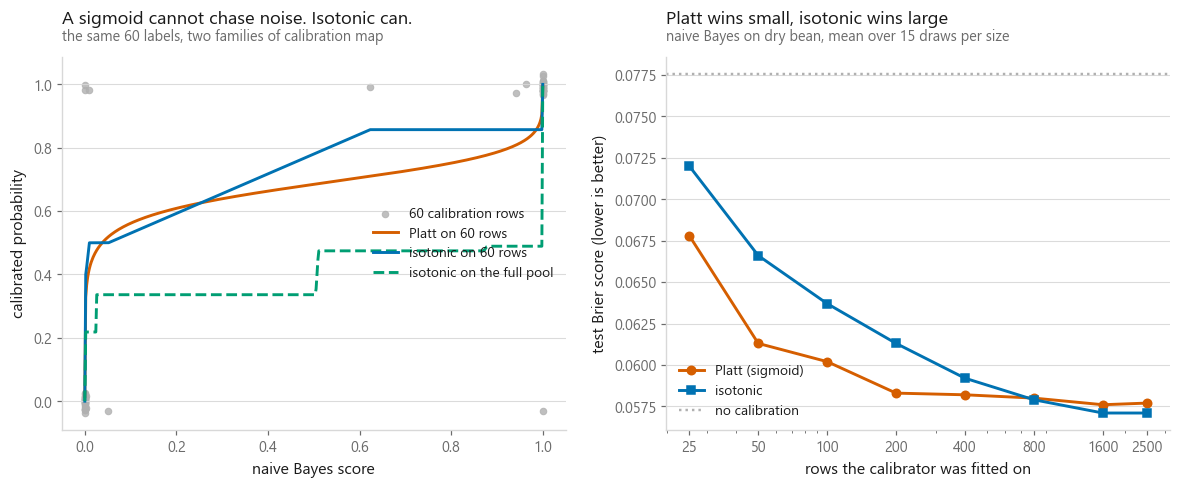

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.4))

# Panel 1: the fitted maps themselves, at a size where isotonic has too little data
small = draw.choice(len(y_cal), 60, replace=False)
grid = np.linspace(s_cal.min(), s_cal.max(), 500)

axes[0].scatter(s_cal[small], y_cal[small] + draw.normal(0, 0.015, len(small)),
                s=18, color=style.NEUTRAL, alpha=0.8, zorder=0, label="60 calibration rows")
axes[0].plot(grid, fit_platt(s_cal[small], y_cal[small], grid),
             color=style.HIGHLIGHT, label="Platt on 60 rows")
axes[0].plot(grid, fit_isotonic(s_cal[small], y_cal[small], grid),
             color=style.PALETTE[0], label="isotonic on 60 rows")
axes[0].plot(grid, fit_isotonic(s_cal, y_cal, grid),
             color=style.PALETTE[2], ls="--", label="isotonic on the full pool")
axes[0].set_xlabel("naive Bayes score")
axes[0].set_ylabel("calibrated probability")
axes[0].legend(loc="center right", fontsize=9)
style.title(axes[0], "A sigmoid cannot chase noise. Isotonic can.",
            "the same 60 labels, two families of calibration map")

# Panel 2: the consequence, measured on a held-out test set
axes[1].plot(sweep["calibration rows"], sweep["Platt Brier"], marker=style.MARKERS[0],
             color=style.HIGHLIGHT, label="Platt (sigmoid)")
axes[1].plot(sweep["calibration rows"], sweep["isotonic Brier"], marker=style.MARKERS[1],
             color=style.PALETTE[0], label="isotonic")
axes[1].axhline(brier_score_loss(y_test, s_test), color=style.NEUTRAL, ls=":", lw=1.6,
                label="no calibration")
axes[1].set_xscale("log")
axes[1].set_xticks(sizes, [str(s) for s in sizes])
axes[1].set_xlabel("rows the calibrator was fitted on")
axes[1].set_ylabel("test Brier score (lower is better)")
axes[1].legend(fontsize=9)
style.title(axes[1], "Platt wins small, isotonic wins large",
            "naive Bayes on dry bean, mean over 15 draws per size")

style.save(fig, FIG / "fig-05-platt-vs-isotonic.png")

crossover = sweep.loc[sweep["winner"].eq("isotonic").idxmax(), "calibration rows"]
print(f"isotonic takes the lead somewhere around {crossover} calibration rows")

The left panel shows the mechanism. With sixty labels the isotonic fit is a
staircase that follows individual points, and the flat runs it invents are
artefacts of which sixty rows I happened to draw. The sigmoid has two parameters
and cannot do that even if the noise invites it. The dashed line is what
isotonic converges to once it has the whole pool, and the small-sample fit is a
long way from it.

The right panel is the practical rule. Below the crossover printed above, Platt
scaling is the safer default. Past it, isotonic starts to pay for its
flexibility, because the shape it can express is closer to the truth than a
sigmoid is. **Sigmoid when the calibration set is small or the miscalibration
looks like a smooth S, isotonic when you have rows to spare.**

## 5. Calibrate on held-out data, always

Everything above quietly obeyed one rule: the calibrator never saw the rows the
base model trained on. That rule is not a nicety.

A model that overfits produces near-perfect scores on its own training rows. A
calibrator fitted there learns that a score of 0.95 means almost certain,
because on those rows it did. On fresh data the same 0.95 means something much
weaker, and the calibrator has been taught the wrong map. It then damages
probabilities that were fine before.

In [16]:
from sklearn.frozen import FrozenEstimator

forest = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1).fit(X_train, y_train)
train_conf = forest.predict_proba(X_train)[:, 1]

print(f"forest accuracy on its own training rows : {accuracy_score(y_train, forest.predict(X_train)):.4f}")
print(f"forest accuracy on the test set          : {accuracy_score(y_test, forest.predict(X_test)):.4f}")
print(f"mean confidence on training rows         : {np.maximum(train_conf, 1 - train_conf).mean():.4f}")

forest accuracy on its own training rows : 1.0000
forest accuracy on the test set          : 0.9261
mean confidence on training rows         : 0.9618


In [17]:
# FrozenEstimator is how scikit-learn 1.8 says "do not refit this model, only fit
# the calibrator". It replaced the old cv="prefit", which no longer works.
placements = {"no calibration": forest.predict_proba(X_test)[:, 1]}

for method in ["sigmoid", "isotonic"]:
    on_train = CalibratedClassifierCV(estimator=FrozenEstimator(forest), method=method)
    on_train.fit(X_train, y_train)                       # the mistake
    placements[f"{method}, fitted on the training rows"] = on_train.predict_proba(X_test)[:, 1]

    on_holdout = CalibratedClassifierCV(estimator=FrozenEstimator(forest), method=method)
    on_holdout.fit(X_cal, y_cal)                         # the fix
    placements[f"{method}, fitted on held-out rows"] = on_holdout.predict_proba(X_test)[:, 1]

# And the version that needs no separate split: cross-fit inside the wrapper, so
# every row is scored by a model that did not see it, then average the calibrators.
cross_fitted = CalibratedClassifierCV(
    estimator=RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    method="isotonic", cv=5).fit(X_fit, y_fit)
placements["isotonic, cross-fitted on everything"] = cross_fitted.predict_proba(X_test)[:, 1]

held_out = pd.DataFrame([{
    "calibration data": name,
    "ECE": round(evaluate.expected_calibration_error(y_test, p, n_bins=15), 4),
    "Brier": round(brier_score_loss(y_test, p), 4),
    "AUC": round(roc_auc_score(y_test, p), 4),
} for name, p in placements.items()])
print(held_out.to_string(index=False))

                     calibration data    ECE  Brier    AUC
                       no calibration 0.0171 0.0515 0.9820
 sigmoid, fitted on the training rows 0.0566 0.0614 0.9820
     sigmoid, fitted on held-out rows 0.0344 0.0528 0.9820
isotonic, fitted on the training rows 0.0651 0.0671 0.9411
    isotonic, fitted on held-out rows 0.0144 0.0523 0.9815
 isotonic, cross-fitted on everything 0.0152 0.0497 0.9836


Fitting the calibrator on the training rows is worse than doing nothing at all,
for both methods. The forest is perfect on those rows, so the calibrator sees a
model that is never wrong and learns to push every score further out.

The cross-fitted version is the one to reach for in practice. It gets held-out
scores from an internal cross-validation loop, so no data is set aside
permanently and the base model still ends up trained on everything.

How much this matters depends on how badly the base model overfits. The same
experiment with naive Bayes, which fits its training rows about as well as it
fits anything else, barely notices.

In [18]:
naive = GaussianNB().fit(X_train, y_train)
print(f"naive Bayes accuracy on training rows : {accuracy_score(y_train, naive.predict(X_train)):.4f}")
print(f"naive Bayes accuracy on the test set  : {accuracy_score(y_test, naive.predict(X_test)):.4f}\n")

for tag, X_c, y_c in [("training rows", X_train, y_train), ("held-out rows", X_cal, y_cal)]:
    fitted = CalibratedClassifierCV(estimator=FrozenEstimator(naive), method="isotonic").fit(X_c, y_c)
    p = fitted.predict_proba(X_test)[:, 1]
    print(f"isotonic fitted on {tag:14s} ECE {evaluate.expected_calibration_error(y_test, p, n_bins=15):.4f}  "
          f"Brier {brier_score_loss(y_test, p):.4f}")

naive Bayes accuracy on training rows : 0.9035
naive Bayes accuracy on the test set  : 0.9121

isotonic fitted on training rows  ECE 0.0176  Brier 0.0569
isotonic fitted on held-out rows  ECE 0.0187  Brier 0.0571


The gap between the two rows is small, and for the forest it was large. The
danger scales with the gap between how well a model fits its training data and
how well it fits everything else, which is the same quantity that
[overfitting](../../01-foundations/03-overfitting-and-underfitting/) is about.
Rather than reason about that per model, fit calibrators on held-out data every
time.

## Cheat sheet

| | |
|---|---|
| **Discrimination** | Does the model order the cases correctly. Measured by AUC. Invariant to any increasing transformation of the score |
| **Calibration** | Does the number mean what it says. Measured by ECE, on a reliability diagram, against the diagonal |
| **Report together** | ECE plus Brier or log loss. ECE alone rewards a model that predicts the base rate and nothing else |
| **Random forest** | Under-confident. Votes average away from 0 and 1, so the reliability curve is an S pushed toward the middle |
| **Naive Bayes** | Over-confident. Correlated features get counted repeatedly, pushing the posterior to the extremes |
| **SVM** | `decision_function` is a distance, not a probability. It needs a fitted map before the number means anything |
| **Logistic regression** | Usually arrives calibrated, because log loss is a proper scoring rule. Check before wrapping it |
| **Platt (`method="sigmoid"`)** | Two parameters. Safe on small calibration sets, exact when the distortion is a smooth S |
| **Isotonic** | Any monotone shape. Needs a large calibration set before it stops chasing noise; the crossover is measured above |
| **Where to fit it** | Never the training rows. Use a held-out split, or let `CalibratedClassifierCV(estimator=..., cv=5)` cross-fit it for you |
| **Prefit models** | `FrozenEstimator(model)` in scikit-learn 1.8. The old `cv="prefit"` has been removed |

## What to remember

1. AUC sees only the order of the scores. A model can rank perfectly and be
   wrong about every probability it reports.
2. A reliability diagram plots mean prediction against observed frequency. Above
   the diagonal is under-confident, below it is over-confident.
3. ECE is a weighted average of the per-bin gaps. It depends on the binning and
   it is not a proper scoring rule, so quote Brier or log loss alongside it.
4. Forests are under-confident because they average votes, though they still
   reach 0 and 1 on cases where every tree agrees; naive Bayes is over-confident
   because it double-counts correlated evidence; an SVM margin is not a
   probability at all, and scores the worst ECE in the chapter.
5. Sigmoid calibration for small calibration sets, isotonic once the calibration
   set is large.
6. Calibration is meant to change what the numbers mean and not their order, so
   in the idealised case AUC is untouched. The map is fitted, though, and a
   saturating sigmoid can tie scores together: naive Bayes lost 0.9877 to 0.9454
   AUC under sigmoid calibration here, while logistic regression gained 0.9953
   to 0.9957. Measure AUC after calibrating instead of assuming it held.
7. Fit the calibrator on data the base model has not seen. On an overfitting
   model, calibrating on the training rows is worse than not calibrating.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [04-01 Bagging](../../04-ensembles/01-bagging/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#Calibration` `#ProbabilityCalibration` `#ReliabilityDiagram`
`#PlattScaling` `#IsotonicRegression` `#Python` `#ScikitLearn` `#DataScience`
`#MLTutorial`